# 正则化与优化

> **斯坦福 CS231n Lecture 3** | Regularization and Optimization

## 本章导读

本节深入讨论如何防止过拟合（正则化）以及如何高效训练模型（优化算法）。我们将从 SGD 到 Adam，逐步理解现代优化器的演进。

**学习目标：**
- 理解 L2 正则化和 Dropout
- 掌握 SGD、Momentum、AdaGrad、Adam 的原理
- 从零实现这些优化器

**参考来源：** [CS231n Optimization](https://cs231n.github.io/optimization-1/) | [Why Momentum Really Works](https://distill.pub/2017/momentum/)

## 1. 正则化：防止过拟合

### L2 正则化

在损失函数中加入权重惩罚：
$$L = \frac{1}{N} \sum_i L_i + \lambda \|W\|^2$$

L2 正则化鼓励权重分散到所有特征上，避免过度依赖少数特征。

### Dropout

训练时随机丢弃神经元：
$$\tilde{h} = \frac{h \cdot \text{mask}}{p}$$

其中 mask 是以概率 $p$ 生成的 0/1 掩列，$p$ 是保留概率。除以 $p$ 是为了保持期望一致（Inverted Dropout）。

## 2. 优化器：从 SGD 到 Adam

### SGD + Momentum

$$v_t = \gamma v_{t-1} + \eta \nabla L(\theta_t)$$
$$\theta_{t+1} = \theta_t - v_t$$

### AdaGrad

$$G_t = G_{t-1} + g_t^2$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t + \epsilon}} g_t$$

### Adam

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t}$$
$$\theta_{t+1} = \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

In [4]:
# 从零实现四种优化器
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

class SGD:
    def __init__(self, params, lr=0.01):
        self.params, self.lr = params, lr
    def step(self, grads):
        for p, g in zip(self.params, grads):
            p -= self.lr * g

class Momentum:
    def __init__(self, params, lr=0.01, momentum=0.9):
        self.params, self.lr, self.momentum = params, lr, momentum
        self.v = [np.zeros_like(p) for p in params]
    def step(self, grads):
        for i, (p, g) in enumerate(zip(self.params, grads)):
            self.v[i] = self.momentum * self.v[i] + self.lr * g
            p -= self.v[i]

class AdaGrad:
    def __init__(self, params, lr=0.01, eps=1e-8):
        self.params, self.lr, self.eps = params, lr, eps
        self.G = [np.zeros_like(p) for p in params]
    def step(self, grads):
        for i, (p, g) in enumerate(zip(self.params, grads)):
            self.G[i] += g ** 2
            p -= self.lr * g / (np.sqrt(self.G[i]) + self.eps)

class Adam:
    def __init__(self, params, lr=0.001, betas=(0.9, 0.999), eps=1e-8):
        self.params, self.lr, self.betas, self.eps = params, lr, betas, eps
        self.m = [np.zeros_like(p) for p in params]
        self.v = [np.zeros_like(p) for p in params]
        self.t = 0
    def step(self, grads):
        self.t += 1
        for i, (p, g) in enumerate(zip(self.params, grads)):
            self.m[i] = self.betas[0] * self.m[i] + (1 - self.betas[0]) * g
            self.v[i] = self.betas[1] * self.v[i] + (1 - self.betas[1]) * g ** 2
            m_hat = self.m[i] / (1 - self.betas[0] ** self.t)
            v_hat = self.v[i] / (1 - self.betas[1] ** self.t)
            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

print("四种优化器实现完成")

四种优化器实现完成


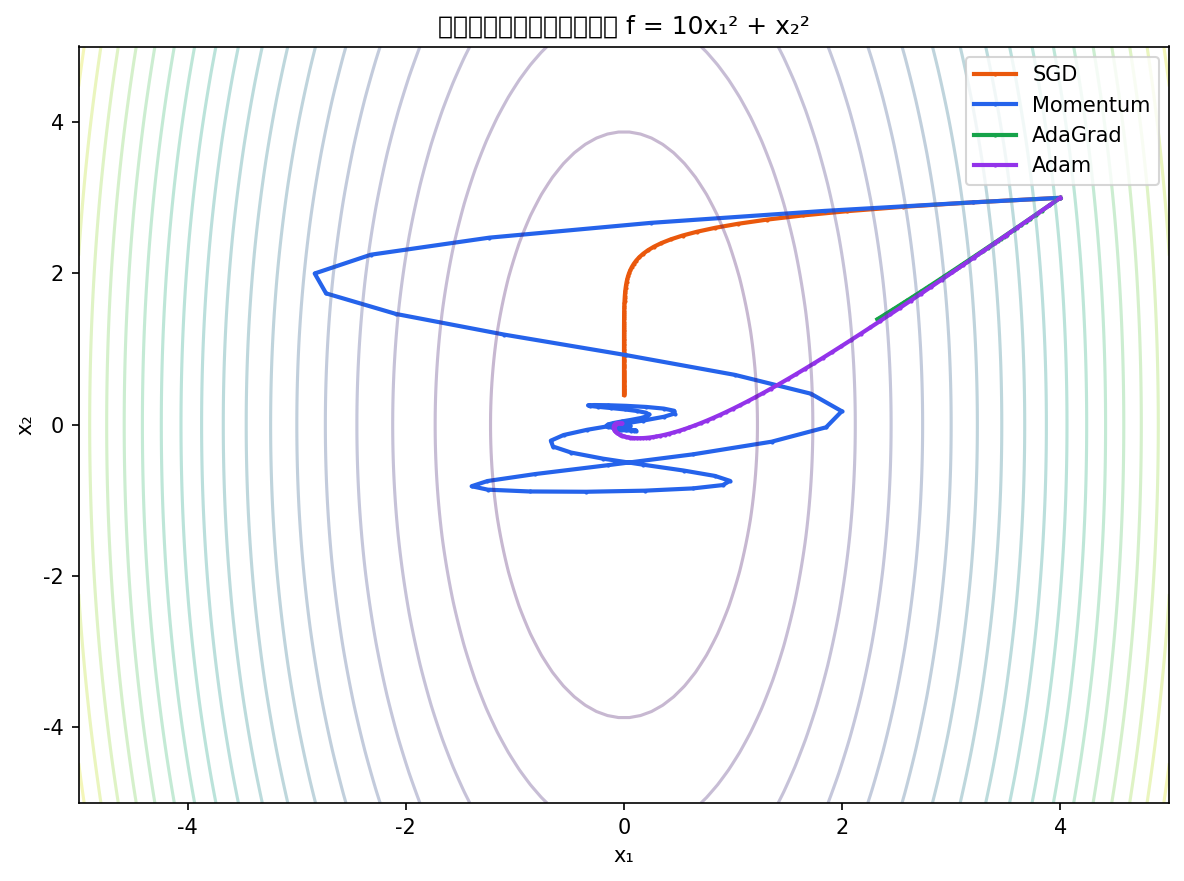

In [5]:
# 在二次损失函数上比较优化器
# f(x, y) = 10*x^2 + y^2 (一个方向比另一个陡峭得多)
def loss_fn(p):
    return 10 * p[0]**2 + p[1]**2

def grad_fn(p):
    return np.array([20 * p[0], 2 * p[1]])

# 初始点
init = np.array([4.0, 3.0])
optimizers = {
    'SGD': SGD([init.copy()], lr=0.01),
    'Momentum': Momentum([init.copy()], lr=0.01),
    'AdaGrad': AdaGrad([init.copy()], lr=0.1),
    'Adam': Adam([init.copy()], lr=0.1),
}

trajectories = {name: [init.copy()] for name in optimizers}
for epoch in range(100):
    for name, opt in optimizers.items():
        p = opt.params[0]
        g = grad_fn(p)
        opt.step([g])
        traject_ories[name].append(p.copy())

# 可视化
fig, ax = plt.subplots(figsize=(8, 6))
colors = {'SGD': '#ea580c', 'Momentum': '#2563eb', 'AdaGrad': '#16a34a', 'Adam': '#9333ea'}
for name, traj in traject_ories.items():
    traj = np.array(traj)
    ax.plot(traj[:, 0], traj[:, 1], label=name, color=colors[name], linewidth=2, marker='.', markersize=2)

# 等高线
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = 10 * X**2 + Y**2
ax.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.3)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('优化器比较：二次损失函数 f = 10x₁² + x₂²')
ax.legend()
plt.tight_layout()
plt.savefig('lecture-03-optimization/optimizers_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 实验观察

从图中可以看到：
- **SGD** 在陡峭方向（x₁）震荡严重，在平坦方向（x₂）进展缓慢
- **Momentum** 通过动量累积，在 x₂ 方向加速
- **AdaGrad** 自适应学习率，在 x₁ 方向自动减小步长
- **Adam** 结合动量和自适应学习率，收敛最快

[[Kingma & Ba, 2015]](https://arxiv.org/abs/1412.6980) Adam 论文

## 作业

### 作业 1：实现 Dropout

完成以下 Dropout 的前向和反向传播：

In [8]:
# 作业 1：实现 Dropout
def dropout_forward(x, p, training=True):
    """Dropout 前向传播
    x: 输入
    p: 丢弃概率（0-1）
    training: 是否训练模式
    """
    if not training:
        return x, None
    mask = None  # 在此实现
    out = None  # 在此实现
    return out, (mask, p)

def dropout_backward(dout, cache):
    """Dropout 反向传播"""
    mask, p = cache
    # 在此实现
    pass

# 测试
x = np.random.randn(10, 5)
out, cache = dropout_forward(x, p=0.3, training=True)
assert out.shape == x.shape
print("作业 1 通过!")

AttributeError: 'NoneType' object has no attribute 'shape'

## 参考文献

1. **Adam: A Method for Stochastic Optimization** - Kingma & Ba, 2015. [arXiv:1412.6980](https://arxiv.org/abs/1412.6980)
2. **Why Momentum Really Works** - Distill, 2017. [distill.pub/2017/momentum](https://distill.pub/2017/momentum/)
3. **Efficient Backprop** - LeCun et al., 1998. [cs231n.stanford.edu/papers/lecun-98b.pdf](https://cs231n.stanford.edu/papers/lecun-98b.pdf)
4. **Dropout** - Srivastava et al., 2014. [JMLR](https://jmlr.org/papers/v15/srivastava14a.html)

---

> 本节内容参考 [Stanford CS231n Lecture 3](https://cs231n.stanford.edu/)